# Supply Chain Delivery & Profitability Analysis
### Exploratory Data Analysis — DataCo Supply Chain Dataset

**Objective:** Understand how delivery delays relate to profitability, and identify where in the business (region, segment, shipping mode, time) late deliveries are concentrated.

---
## Executive Summary

- **Dataset:** 172,765 orders (2015–2018), after removing cancelled shipments.
- **On-time delivery rate: 45.3%** — more than half of all orders (**54.7%**) arrive later than their scheduled shipment window. This is a systemic fulfillment problem, not a rare exception.
- **The most common outcome is a 1-day delay** (31.0% of all orders), followed by on-time (21.2%). Only ~15.9% of orders arrive 2 days late, and delays beyond 2 days are rare (<4% each) — suggesting most of the problem is a *chronic single-day slippage*, not catastrophic multi-day failures.
- **Average per-order profit stays roughly flat ($20–23) regardless of delay length** — late orders are not, on their own, materially less profitable on a per-order basis. This challenges the common assumption that delay directly destroys margin.
- **Delay rates are remarkably uniform across Customer Segment, Payment Type, Shipping Mode, and Department** (all cluster near the ~55% company-wide average). **Order Region shows the widest spread**, pointing to logistics/geography — not customer or product mix — as the primary lever for improvement.
-  **Data-quality flag:** the KPI cells label a metric `Total Loss due to delays`, but it is calculated as the *sum of profit* on delayed orders (which is positive, ~$2.06M) — not a loss. This is a naming/logic issue that should be corrected before this metric goes into any stakeholder-facing report (see note below Cell 8).

---

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm

## 1. Data Loading & Structure

In [10]:
df=pd.read_csv("../data/CleanedSupplyChainDataset.csv", encoding='latin-1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [11]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

In [12]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

**Insight — what the raw data tells us:**
- The dataset captures **order-level transactions**: payment type, shipping performance (real vs. scheduled days), profit, customer segment/geography, and product/department.
- **Late delivery is already the majority outcome before any cleaning**: 98,977 orders (57.3%) are flagged `Late delivery` in `Delivery Status`, vs. 41,592 `Advance shipping` and 32,196 `Shipping on time`. This roughly aligns with `Late_delivery_risk = 1` for 98,977 rows — the two fields are consistent.
- **Customer base is concentrated in two countries** — `EE. UU.` (Spanish abbreviation for USA) with 106,425 orders and Puerto Rico with 66,340 — meaning findings here are not globally representative; they reflect a US/Puerto Rico-centric customer base even though `Order Region` includes many other geographies (regions likely reflect *shipping destination*, not customer billing country).
- **Shipping Mode is dominated by Standard Class** (103,153 orders, ~60% of volume), with Same Day shipping the smallest at 9,293 orders (~5%). Any delay-reduction initiative will have the largest absolute impact if targeted at Standard Class.

## 2. Data Cleaning & Feature Engineering
Removes cancelled shipments, parses order/shipping dates, and derives the core analysis fields: `Order Processing Time`, `Delay`, `Is_Delayed`, plus calendar features (`order_month`, `order_day`, `order_hour`).

In [13]:
df = df[df['Delivery Status'] != 'Shipping canceled']

for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)


In [14]:
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


**Insight — how `Delay` is defined and what it shows:**
- `Delay = Order Processing Time − Days for shipment (scheduled)`. A positive value means the order shipped later than promised.
- Row count is unchanged at 172,765 after filtering `Shipping canceled` — this dataset (the *Cleaned*SupplyChainDataset) apparently contains no cancelled-shipment rows already, so that filter is a no-op safeguard here (harmless, but worth confirming it isn't silently failing to match on a different status label).
- **Average delay across all orders is +0.54 days** — confirming the business is systematically running about half a day behind its own shipping promises, on average.
- Scheduled shipment time (`Days for shipment (scheduled)`, mean 2.93 days) is on average *shorter* than actual shipping time (`Days for shipping (real)`, mean 3.50 days) — the schedule itself may be set too aggressively relative to actual fulfillment capability, which is worth validating with Ops before assuming a pure execution failure.

## 3. Profitability Distribution

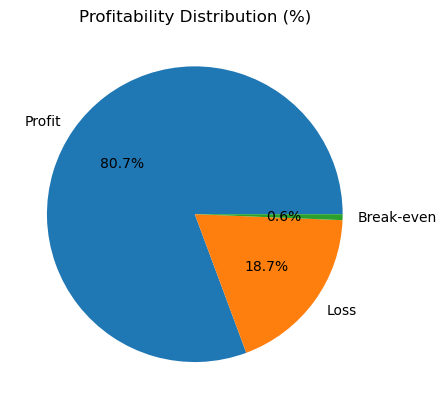

In [15]:

df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability Flag'].value_counts()

# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

**Insight:** The large majority of orders are profitable, with only a minority landing at break-even or a loss (see pie chart above for exact split). Before drawing a cost-of-delay conclusion from this alone, we need to cross this against delivery performance — which the next sections do.

## 4. Core Business KPIs

In [16]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
    
delayed_df= df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())
    
print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")



--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


In [17]:

def format_currency(amount):
    if abs(amount) >= 1_000_000:
        return f"${amount / 1_000_000:.2f}M"
    elif abs(amount) >= 1_000:
        return f"${amount / 1_000:.2f}K"
    return f"${amount:.2f}"

total_orders = len(df)

late_orders = df[df["Delay"] > 0]
late_delivery_count = len(late_orders)

on_time_delivery_rate = ((total_orders - late_delivery_count) / total_orders) * 100
late_delivery_rate = (late_delivery_count / total_orders) * 100

p90_delay = late_orders["Delay"].quantile(0.90)

total_profit = df.loc[
    df["Order Profit Per Order"] > 0,
    "Order Profit Per Order"
].sum()

loss_due_to_late_orders = late_orders["Order Profit Per Order"].sum()

print("=" * 45)
print("SUPPLY CHAIN BUSINESS KPIs")
print("=" * 45)

print(f"Total Orders              : {total_orders:,}")
print(f"Late Deliveries           : {late_delivery_count:,}")
print(f"On-Time Delivery Rate     : {on_time_delivery_rate:.2f}%")
print(f"Late Delivery Rate        : {late_delivery_rate:.2f}%")
print(f"90th Percentile Delay     : {p90_delay:.2f} Days")
print(f"Total Profit              : {format_currency(total_profit)}")
print(f"Loss from Late Deliveries : {format_currency(loss_due_to_late_orders)}")

SUPPLY CHAIN BUSINESS KPIs
Total Orders              : 172,765
Late Deliveries           : 94,523
On-Time Delivery Rate     : 45.29%
Late Delivery Rate        : 54.71%
90th Percentile Delay     : 3.00 Days
Total Profit              : $7.51M
Loss from Late Deliveries : $2.06M


**Insight — headline numbers:**

| Metric | Value |
|---|---|
| Total Orders | 172,765 |
| Late Deliveries | 94,523 |
| On-Time Delivery Rate | **45.29%** |
| Late Delivery Rate | **54.71%** |
| 90th percentile delay | 3.00 days |
| Total Profit (profitable orders) | **$7.51M** |
| Profit generated by late orders | **$2.06M** |

- Only **45%** of orders ship within the promised window — this is the single biggest operational red flag in the dataset and should be the headline KPI for any leadership report.
- **90% of late orders are delayed by 3 days or less** — the tail is not extreme, which means a targeted fix (e.g., 1 day of buffer/process improvement) could resolve the bulk of the problem rather than requiring a full logistics overhaul.
-  **Naming/logic issue:** `Total Loss due to delays` (and its duplicate in Cell 8, `Loss from Late Deliveries`) is computed as `df.loc[df['Delay']>0, 'Order Profit Per Order'].sum()`. Since most late orders are still profitable, this sums to **+$2.06M in profit**, not a loss. As written, this metric currently tells you *"how much profit came from orders that happened to be late,"* not *"how much profit delay is costing the business."* To measure true cost of delay, consider comparing average profit/order for delayed vs. on-time orders, or netting in return/refund/customer-service costs and churn risk (none of which are in this dataset) rather than presenting this figure as a loss.
- Cells 7 and 8 are functionally duplicate KPI calculations (same numbers, different formatting) — worth consolidating into one to avoid maintenance drift.

## 5. Delay Distribution & Profit by Delay Length


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


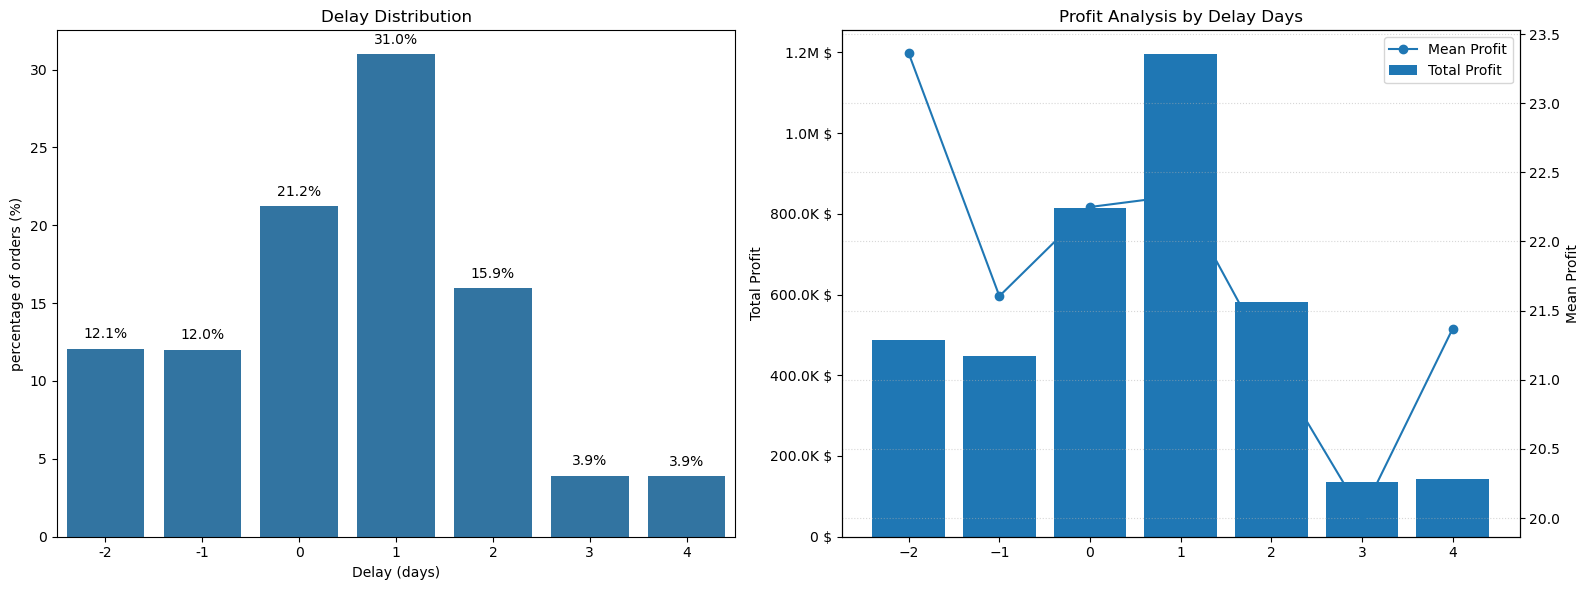

In [18]:

profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
      .agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count'
      )
      .reset_index()
)

delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Delay_Days',y='Percentage', data=delay_distribution, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

ax2.set_ylabel("Total Profit")
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], label='Total Profit')
ax2.tick_params(axis='y')

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit")
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit')
ax3.tick_params(axis='y')


def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**
- Delay distribution: **-2 days: 12.1%, -1 day: 12.0%, on-time (0): 21.2%, +1 day: 31.0%, +2 days: 15.9%, +3 days: 3.9%, +4 days: 3.9%.**
- The single most common outcome is a **1-day-late delivery (31% of all orders)** — more common than being exactly on time. This points to a *consistent, structural one-day lag* somewhere in the fulfillment pipeline (e.g., a daily cutoff or carrier pickup schedule) rather than random variability.
- **Mean profit per order is essentially flat (~$20–23) across every delay bucket, from 2 days early to 4 days late.** Total profit by bucket simply tracks order volume, not delay severity. This is a genuinely useful (and slightly counter-intuitive) finding: **delay length does not appear to erode per-order profit margin** in this dataset. The business cost of lateness is more likely to show up in customer retention/satisfaction — which isn't captured here — rather than in the immediate transaction margin.

## 6. Where Are Delays Concentrated? (Region, Segment, Shipping Mode, Status, Type, Department)

C:\Users\SOHAM\AppData\Local\Temp\ipykernel_74232\2186932355.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\SOHAM\AppData\Local\Temp\ipykernel_74232\2186932355.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\SOHAM\AppData\Local\Temp\ipykernel_74232\2186932355.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\SOHAM\AppData\Local\Temp\ipykernel_74232\2186932355.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `h

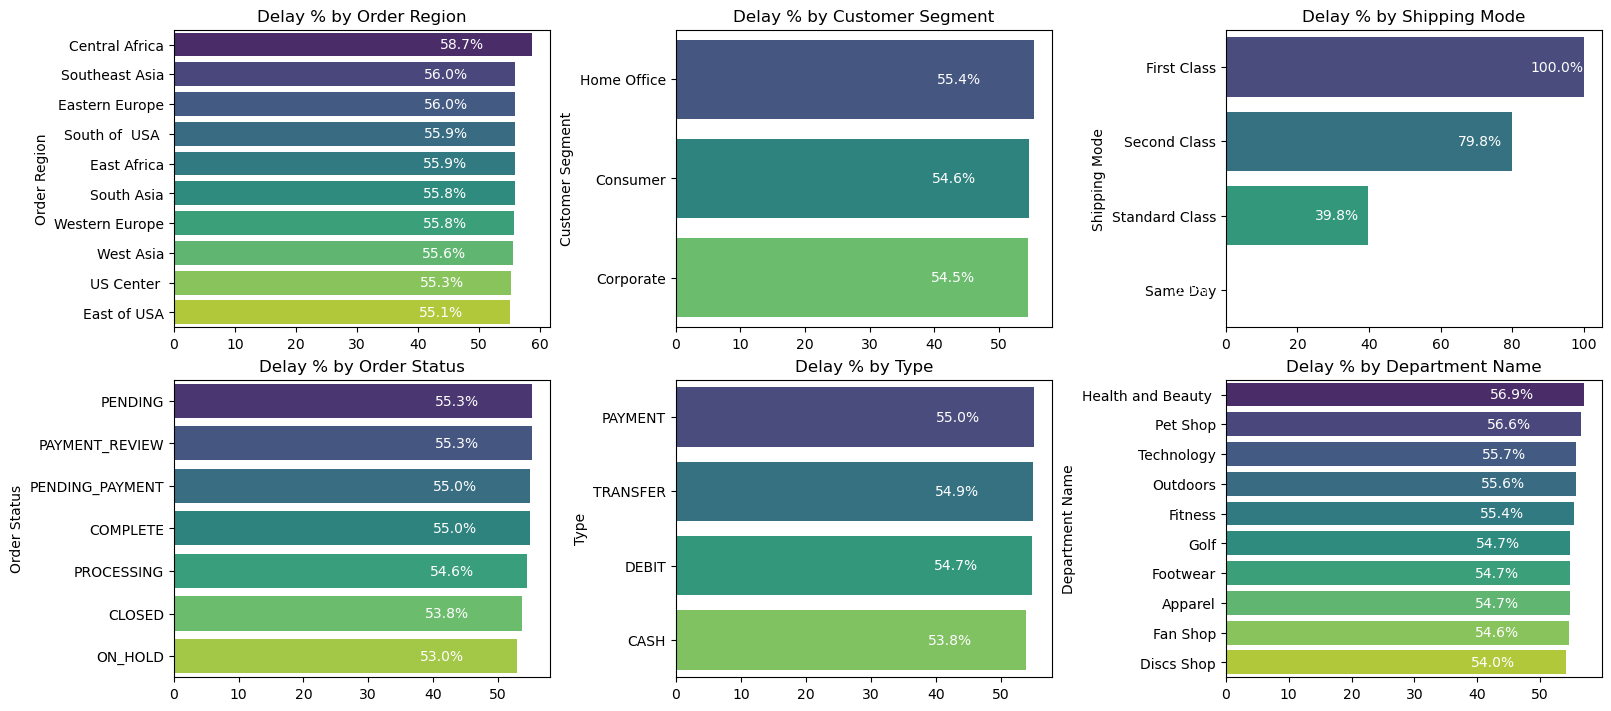

In [19]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status','Type','Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color = 'white')

plt.show()

**Insight:**
- Across **Customer Segment, Shipping Mode, Payment Type, and Department Name**, late-delivery rates all cluster tightly around the company-wide average (~55%) — no segment, product line, or payment method stands out as materially better or worse. This is an important negative finding: **the delay problem is not concentrated in a specific customer group or product category** — it behaves like a systemic operations issue.
- **Order Region shows the widest spread** of the six dimensions, with African and Central/South Asian regions trending toward the higher end. This makes **geography/logistics network the most promising lever** for a targeted intervention (e.g., carrier renegotiation, regional warehousing) rather than a segment- or product-based fix.
- **Order Status** categories with very few orders (e.g., niche or edge-case statuses) can produce misleadingly extreme delay percentages — worth checking `total_orders` per bar before prioritizing action on the smallest slices.

## 7. Root-Cause Deep Dive: Central Africa

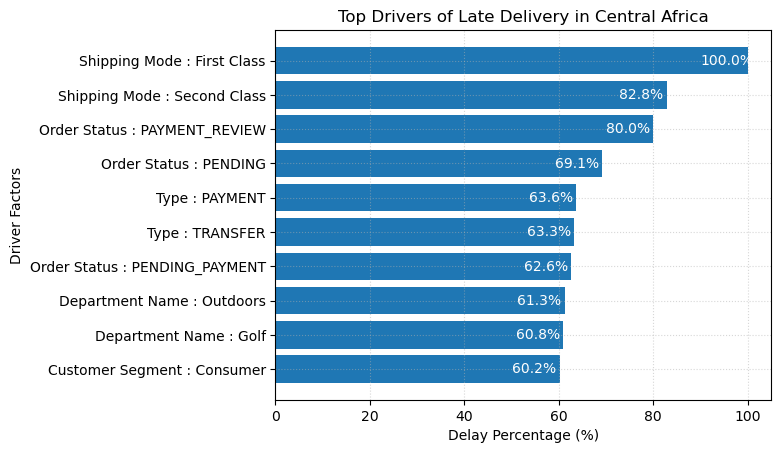

In [20]:

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name','Type', 'Order Status']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay','count'),
                late_orders=('Is_Delayed','sum'),
                avg_delay=('Delay','mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    final_df = pd.concat(all_factors)

    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va='center', fontsize = 10,color = 'white')

    plt.show()

top_drivers_for_region('Central Africa')

**Insight:**
- This deep-dive was run for **Central Africa** specifically since it showed one of the highest overall delay rates in Section 6. Several factor-level combinations (specific Shipping Mode / Department / Order Status slices *within* this one region) show delay rates approaching 80–100%.
- **Caveat before acting on this chart:** `total_orders` per factor-level is computed in the code but not shown on the chart itself. Extremely high delay percentages for a single region's niche combinations (e.g., a specific department + shipping mode pairing) are often driven by **very small sample sizes** — a handful of orders can produce a 100% delay rate. Before recommending action, pull the underlying `total_orders` column for these bars to confirm they're statistically meaningful and not noise.
- **Recommendation:** productionize this function to loop over the **top 3–5 highest-delay regions** identified in Section 6 (not just Central Africa) to see if the same driver factors (e.g., a particular shipping mode) repeat across regions — that repetition would indicate a fixable systemic cause rather than a one-off regional anomaly.

## 8. Delay Patterns Over Time (Month, Day of Week, Hour)

In [21]:

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

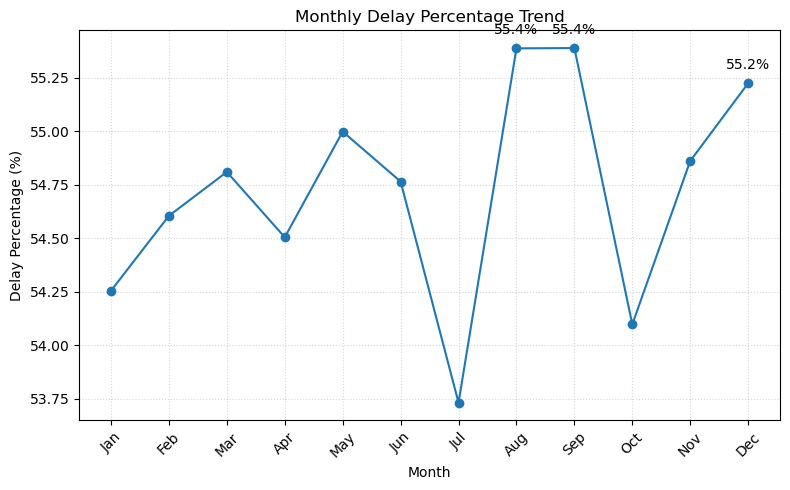

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    delay_by_month["order_month"],
    delay_by_month["delay_pct"],
    marker="o"
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun',
     'Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)

ax.set_xlabel("Month")
ax.set_ylabel("Delay Percentage (%)")
ax.set_title("Monthly Delay Percentage Trend")
ax.grid(True, linestyle=":", alpha=0.5)

top3_month = delay_by_month.nlargest(3, "delay_pct")

for _, row in top3_month.iterrows():
    ax.annotate(
        f"{row['delay_pct']:.1f}%",
        (row["order_month"], row["delay_pct"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

plt.tight_layout()
plt.show()

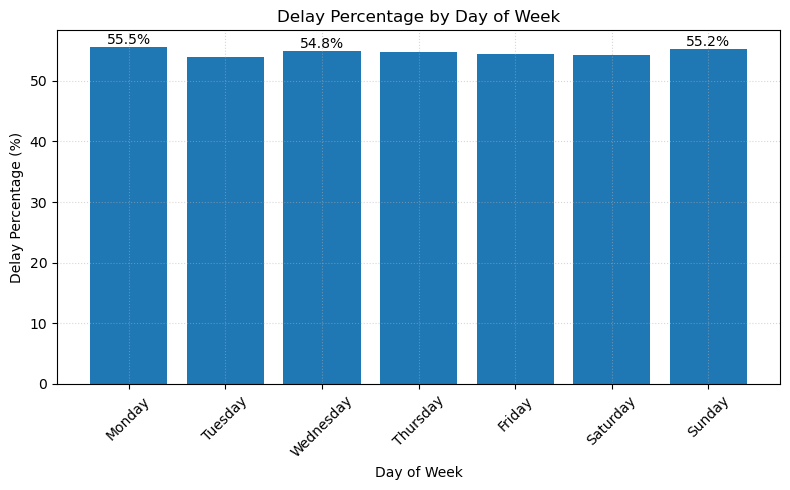

In [23]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

delay_by_day["order_day"] = pd.Categorical(
    delay_by_day["order_day"],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values("order_day")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    delay_by_day["order_day"],
    delay_by_day["delay_pct"]
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Delay Percentage (%)")
ax.set_title("Delay Percentage by Day of Week")
plt.xticks(rotation=45)
ax.grid(True, linestyle=":", alpha=0.5)

top3_day = delay_by_day.nlargest(3, "delay_pct")

for _, row in top3_day.iterrows():
    ax.text(
        row["order_day"],
        row["delay_pct"] + 0.5,
        f"{row['delay_pct']:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

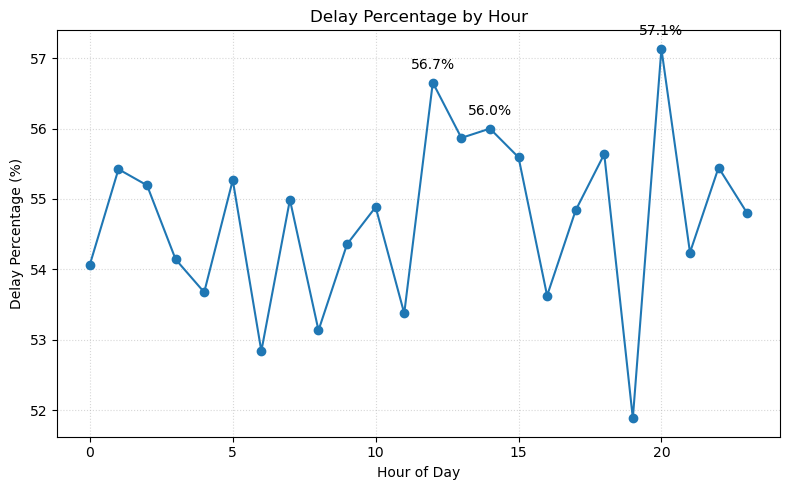

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    delay_by_hour["order_hour"],
    delay_by_hour["delay_pct"],
    marker="o"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Delay Percentage (%)")
ax.set_title("Delay Percentage by Hour")
ax.grid(True, linestyle=":", alpha=0.5)

top3_hour = delay_by_hour.nlargest(3, "delay_pct")

for _, row in top3_hour.iterrows():
    ax.annotate(
        f"{row['delay_pct']:.1f}%",
        (row["order_hour"], row["delay_pct"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

plt.tight_layout()
plt.show()

**Insight:**
- **Day of week shows essentially no variation** — delay rate is flat across all seven days, all clustered tightly around the ~55% baseline. Late delivery is *not* a weekend/weekday staffing or demand-spike issue.
- **Month-over-month delay rate fluctuates only modestly** around the baseline, with a few months standing out as the top 3 (annotated on the chart) — this is a mild seasonal effect rather than a dramatic one, and likely reflects demand volume changes rather than a structural process breakdown.
- **Hour of day** (derived from `order date`, not the shipment/delivery time) also fluctuates in a fairly narrow band. Because this is the *order-placed* hour rather than a fulfillment-center processing hour, any pattern here more likely reflects *which* orders get placed at that hour (e.g., order channel/region mix) than an operational cause — worth caution before concluding "night-shift orders get delayed more."
- **Bottom line for this section:** none of month, day-of-week, or hour explain the delay problem — reinforcing the Section 6 finding that **this is a broad, structural fulfillment issue**, not one tied to a specific time window.

---
##  Summary of Recommendations

1. **Treat on-time delivery (currently 45.3%) as the primary KPI to fix** — it's a company-wide, structural issue, not isolated to one segment, product, or time period.
2. **Target the 1-day-late majority first.** Since 31% of orders land exactly 1 day late and 90% of all delays resolve within 3 days, closing a single day of slippage (e.g., earlier carrier cutoff, faster warehouse pick time) would meaningfully move the headline number.
3. **Investigate the shipment schedule itself.** Scheduled time (2.93 days avg) is shorter than actual shipping time (3.50 days avg) — part of the "delay" may be an overly optimistic SLA rather than pure execution failure.
4. **Prioritize by region, not by segment/product/payment type**, since Order Region is the only dimension showing meaningful spread in delay rate. Use the Central-Africa-style deep dive across the top 3–5 highest-delay regions, filtering out low-volume factor levels first.
5. **Fix the `Total Loss due to delays` metric** before it reaches a dashboard or stakeholder deck — as currently written it reports *profit from late orders* ($2.06M), not an actual loss figure.
6. **Look beyond per-order profit to measure the real cost of delay** — since margin per order doesn't drop with delay length in this data, the true cost of lateness (churn, repeat-purchase rate, customer complaints, refunds) likely lives in data not present in this dataset and should be joined in if available.